# Set 06 — AI-Driven High Energy Physics

Completed assignment solution.

# Exercise 01: Differentiable programming

The effective potential is

$$
V_{\mathrm{eff}}(r)
=
\frac{\ell^2}{2r^2}
-\frac{r_s}{2r}
-\frac{r_s\ell^2}{2r^3}.
$$

The first-order equation

$$
\frac12\left(\frac{dr}{ds}\right)^2+V_{\mathrm{eff}}(r)=E
$$

gives

$$
E
=
\frac12\left(\frac{dr}{ds}\right)^2+V_{\mathrm{eff}}(r).
$$

The corresponding radial acceleration follows from differentiating the energy equation:

$$
\frac{d^2r}{ds^2}
=
-\frac{dV_{\mathrm{eff}}}{dr}.
$$

For the given potential,

$$
\frac{dV_{\mathrm{eff}}}{dr}
=
-\frac{\ell^2}{r^3}
+\frac{r_s}{2r^2}
+\frac{3r_s\ell^2}{2r^4}.
$$

Therefore

$$
\boxed{
\frac{d^2r}{ds^2}
=
\frac{\ell^2}{r^3}
-\frac{r_s}{2r^2}
-\frac{3r_s\ell^2}{2r^4}
}.
$$

The code below uses PyTorch tensors and automatic differentiation to calculate the force from the effective potential. This demonstrates differentiable programming while numerically integrating the trajectory.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

torch.set_default_dtype(torch.float64)

def effective_potential(r, ell, r_s):
    return (
        ell**2 / (2.0 * r**2)
        - r_s / (2.0 * r)
        - r_s * ell**2 / (2.0 * r**3)
    )

def radial_acceleration(r_value, ell, r_s):
    # Autograd calculation of -dV/dr
    r = torch.tensor(float(r_value), requires_grad=True)
    V = effective_potential(r, ell, r_s)
    dVdr = torch.autograd.grad(V, r)[0]
    return float((-dVdr).detach())

def integrate_trajectory(ell, r_s, r0=None, v0=0.1, ds=0.02, n_steps=30000):
    if r0 is None:
        r0 = 10.0 * r_s

    r = float(r0)
    v = float(v0)

    E = 0.5 * v**2 + float(effective_potential(
        torch.tensor(r0), ell, r_s
    ))

    rs = [r]
    vs = [v]
    ss = [0.0]

    # Velocity-Verlet integration.
    for step in range(n_steps):
        a = radial_acceleration(r, ell, r_s)

        v_half = v + 0.5 * ds * a
        r_new = r + ds * v_half

        # Stop before crossing the singular/invalid region.
        if r_new <= r_s * 1.0001:
            break

        a_new = radial_acceleration(r_new, ell, r_s)
        v_new = v_half + 0.5 * ds * a_new

        # Numerical check of the allowed region.
        V_new = float(effective_potential(torch.tensor(r_new), ell, r_s))
        if E - V_new < -1e-5:
            break

        r, v = r_new, v_new
        rs.append(r)
        vs.append(v)
        ss.append((step + 1) * ds)

        # Stop after the particle has clearly escaped.
        if r > 100.0 * r_s:
            break

    return np.array(ss), np.array(rs), np.array(vs), E

# Example trajectory
s, r, v, E = integrate_trajectory(
    ell=4.0,
    r_s=1.0,
    r0=10.0,
    v0=0.1,
)

print("Initial energy:", E)
print("Integrated points:", len(r))
print("Final radius:", r[-1])

Initial energy: 0.027
Integrated points: 17923
Final radius: 100.00306517079483


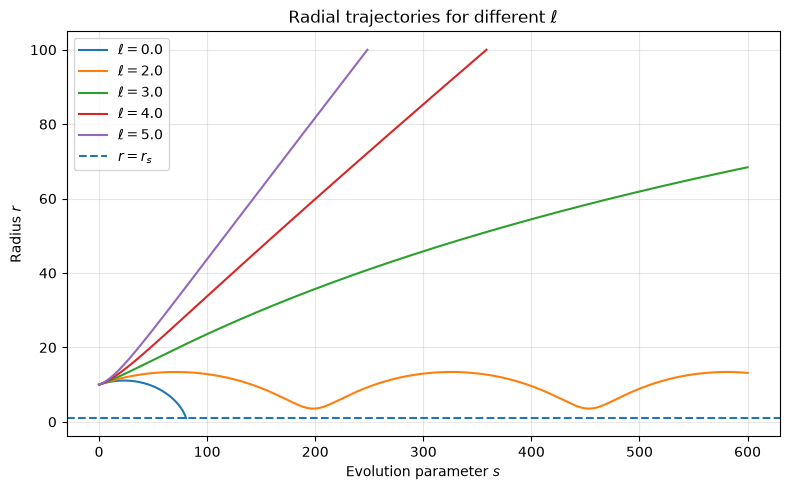

In [2]:
# Compare trajectories for different angular momenta ell.
r_s = 1.0
ell_values = [0.0, 2.0, 3.0, 4.0, 5.0]

plt.figure(figsize=(8, 5))

for ell in ell_values:
    s, r, v, E = integrate_trajectory(
        ell=ell,
        r_s=r_s,
        r0=10.0 * r_s,
        v0=0.1,
    )
    plt.plot(s, r, label=fr"$\ell={ell}$")

plt.axhline(r_s, ls="--", label=r"$r=r_s$")
plt.xlabel(r"Evolution parameter $s$")
plt.ylabel(r"Radius $r$")
plt.title(r"Radial trajectories for different $\ell$")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

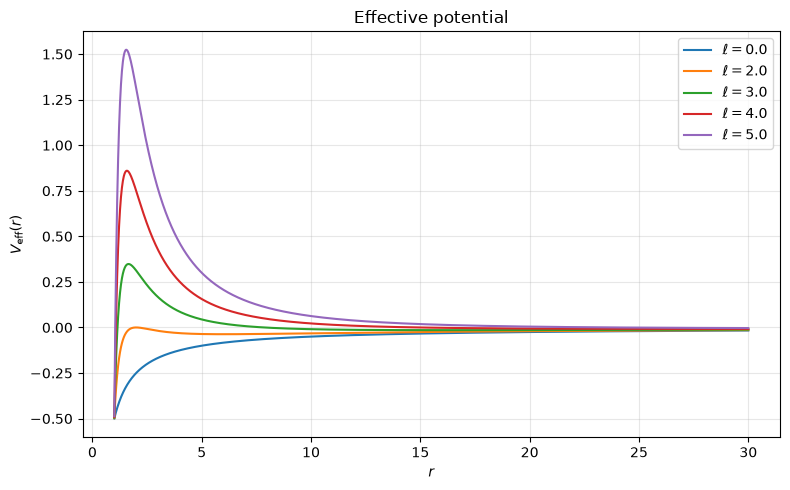

In [3]:
# Compare the effective potential for different ell values.
r_s = 1.0
r_grid = torch.linspace(1.001 * r_s, 30.0 * r_s, 2000)

plt.figure(figsize=(8, 5))

for ell in [0.0, 2.0, 3.0, 4.0, 5.0]:
    V = effective_potential(r_grid, ell, r_s)
    plt.plot(r_grid.numpy(), V.detach().numpy(), label=fr"$\ell={ell}$")

plt.xlabel(r"$r$")
plt.ylabel(r"$V_{\mathrm{eff}}(r)$")
plt.title("Effective potential")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Circular motion

A circular orbit requires

$$
\frac{dV_{\mathrm{eff}}}{dr}=0.
$$

Using

$$
-\frac{\ell^2}{r^3}
+\frac{r_s}{2r^2}
+\frac{3r_s\ell^2}{2r^4}=0,
$$

multiplying by $2r^4$ gives

$$
r_s r^2-2\ell^2 r+3r_s\ell^2=0.
$$

Thus the possible circular radii are

$$
\boxed{
r_{\pm}
=
\frac{\ell^2\pm
\ell\sqrt{\ell^2-3r_s^2}}{r_s}
}.
$$

Real circular solutions exist only when

$$
\boxed{\ell^2\ge 3r_s^2}.
$$

The code below calculates these candidate radii and checks the curvature of the effective potential. A positive second derivative corresponds to a local minimum (stable circular orbit), while a negative second derivative corresponds to a local maximum (unstable circular orbit).

In [4]:
def circular_radii(ell, r_s):
    if ell**2 < 3.0 * r_s**2:
        return []

    root = ell * np.sqrt(ell**2 - 3.0 * r_s**2)
    r_minus = (ell**2 - root) / r_s
    r_plus = (ell**2 + root) / r_s

    return [r_minus, r_plus]

def second_derivative_V(r_value, ell, r_s):
    r = torch.tensor(float(r_value), requires_grad=True)
    V = effective_potential(r, ell, r_s)
    dVdr = torch.autograd.grad(V, r, create_graph=True)[0]
    d2Vdr2 = torch.autograd.grad(dVdr, r)[0]
    return float(d2Vdr2.detach())

r_s = 1.0

for ell in [1.0, np.sqrt(3), 2.0, 3.0, 4.0, 5.0]:
    radii = circular_radii(ell, r_s)

    print(f"\nell = {ell:.4f}")
    if not radii:
        print("  No real circular orbit.")
        continue

    for r_c in radii:
        curvature = second_derivative_V(r_c, ell, r_s)
        stability = "stable" if curvature > 0 else "unstable"
        print(
            f"  r_c = {r_c:.6f} | "
            f"d2V/dr2 = {curvature:.6e} | {stability}"
        )


ell = 1.0000
  No real circular orbit.

ell = 1.7321
  No real circular orbit.

ell = 2.0000
  r_c = 2.000000 | d2V/dr2 = -1.250000e-01 | unstable
  r_c = 6.000000 | d2V/dr2 = 1.543210e-03 | stable

ell = 3.0000
  r_c = 1.651531 | d2V/dr2 = -9.877572e-01 | unstable
  r_c = 16.348469 | d2V/dr2 = 1.028699e-04 | stable

ell = 4.0000
  r_c = 1.577795 | d2V/dr2 = -2.327177e+00 | unstable
  r_c = 30.422205 | d2V/dr2 = 1.683716e-05 | stable

ell = 5.0000
  r_c = 1.547921 | d2V/dr2 = -4.084943e+00 | unstable
  r_c = 48.452079 | d2V/dr2 = 4.255315e-06 | stable


### Interpretation

- The allowed region satisfies $E-V_{\mathrm{eff}}\ge 0$.
- Different values of $\ell$ change the centrifugal contribution and can create a local minimum and maximum in the effective potential.
- Circular solutions appear only when $\ell^2\ge 3r_s^2$.
- For two circular solutions, the local minimum of $V_{\mathrm{eff}}$ corresponds to the stable orbit and the local maximum corresponds to the unstable orbit.

This notebook uses PyTorch automatic differentiation to compute derivatives of the potential, while the numerical trajectory is integrated with a velocity-Verlet scheme.